In [24]:
# Imports
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler

print('Libraries loaded!')
print('GPU available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Libraries loaded!
GPU available: True
Device: Tesla T4


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Untitled document (3).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', 'Hw1.gdoc', 'Article Paraphrasing Exercise.gdoc', 'Novice Document.gdoc', 'CS157 Assignment2.gdoc', 'Project Proposal Topic Selection.gdoc', 'CSC 157C.gdoc', 'CS258 midterm review .gdoc', 'Individual tasks 157C.gdoc', 'Project Proposal Final.gdoc', 'CS157C Assignment 3.gdoc', 'midterm.gdoc', 'Untitled document.gdoc', 'Network Bandwidth Monitoring.gslides', 'Script.gdoc', 'hw4.gdoc', 'Team Tasks CS 157C.gdoc', 'Literature Review Final Draft.gdoc', 'Research Project Problem Definition and Summary.gdoc', 'FakeAVCeleb_v1.2', 'FakeAVCeleb_v1.2.zip', 'Assignment 2 report.gdoc', 'Notes for presentation.gdoc', 'sgd_mean_ackley.npy', 'rand_mean_ackley.npy', 'convergence_mnist.png', 'rand_final_ackley.npy', 'sgd_losses_mnist.npy', 'rr_final_ackley.npy', 'rr_mean_ackley.npy', 'rr_losses_mnist.npy', 'sgd_final_ackley.npy', 'rand_losses_mnist.npy', 'ackley_plot.png', 'chebyshev_plot.png', '

In [27]:
# Load datasets
NAZARIO_PATH = '/content/drive/MyDrive/Nazario.csv/Nazario.csv'
SPAM_PATH    = '/content/drive/MyDrive/spam_ham_dataset.csv/spam_ham_dataset.csv'

nazario = pd.read_csv(NAZARIO_PATH)
spam    = pd.read_csv(SPAM_PATH)

nazario_clean = nazario[['body', 'label']].copy()
nazario_clean.columns = ['text', 'label']

spam_clean = spam[['text', 'label_num']].copy()
spam_clean.columns = ['text', 'label']

df = pd.concat([nazario_clean, spam_clean], ignore_index=True)
df.dropna(inplace=True)
df['label'] = df['label'].astype(int)
df.reset_index(drop=True, inplace=True)

print(f'Total samples: {len(df)}')
print(df['label'].value_counts())

Total samples: 6736
label
0    3672
1    3064
Name: count, dtype: int64


In [28]:
# Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
print('Cleaning done!')

Cleaning done!


In [29]:
# Train/test split
X_text = df['text_clean'].values
y      = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train_text)} samples')
print(f'Test : {len(X_test_text)} samples')

Train: 5388 samples
Test : 1348 samples


In [30]:
# Character substitution for adversarial manipulation
CHAR_MAP = {'a':'@', 'o':'0', 'i':'1', 'e':'3', 's':'$', 'l':'1', 'g':'9', 't':'7'}

def substitute_chars(text):
    return ''.join(CHAR_MAP.get(c, c) for c in str(text))

X_test_manip_text = [substitute_chars(t) for t in X_test_text]

print('Original   :', X_test_text[0][:80])
print('Manipulated:', X_test_manip_text[0][:80])

Original   : subject new turn ons tom production commenced to flow as stated below please cre
Manipulated: $ubj3c7 n3w 7urn 0n$ 70m pr0duc710n c0mm3nc3d 70 f10w @$ $7@73d b310w p13@$3 cr3


In [31]:
# Robust training data — stack clean + manipulated
X_train_manip       = [substitute_chars(t) for t in X_train_text]
X_train_robust_text = list(X_train_text) + X_train_manip
y_train_robust      = np.concatenate([y_train, y_train])

print(f'Robust training size: {len(X_train_robust_text)}')

Robust training size: 10776


In [32]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [33]:
# Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

In [34]:
# Dataset class
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

In [35]:
from torch.utils.data import random_split

# Create datasets
train_dataset      = EmailDataset(X_train_robust_text, y_train_robust, tokenizer)
test_clean_dataset = EmailDataset(X_test_text,         y_test,         tokenizer)
test_manip_dataset = EmailDataset(X_test_manip_text,   y_test,         tokenizer)

# Split train into train and validation (85/15)
val_size   = int(0.15 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create dataloaders
train_loader      = DataLoader(train_subset,       batch_size=16, shuffle=True)
val_loader        = DataLoader(val_subset,         batch_size=16)
test_clean_loader = DataLoader(test_clean_dataset, batch_size=16)
test_manip_loader = DataLoader(test_manip_dataset, batch_size=16)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_clean_loader)}')

Train batches: 573
Val batches  : 101
Test batches : 85


In [36]:
# Load DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model.to(device)
print('Model loaded on', device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda


In [37]:
# Training setup
EPOCHS = 5
optimizer = AdamW(model.parameters(), lr=2e-5)
num_training_steps = EPOCHS * len(train_loader)

lr_scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

In [38]:
train_acc_history  = []
train_loss_history = []
val_acc_history    = []
val_loss_history   = []

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    avg_train_loss = total_loss / len(train_loader)
    avg_train_acc  = correct / total

    # Validation
    model.eval()
    val_loss    = 0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss
            logits  = outputs.logits

            val_loss    += loss.item()
            preds        = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = val_correct / val_total

    train_acc_history.append(avg_train_acc)
    train_loss_history.append(avg_train_loss)
    val_acc_history.append(avg_val_acc)
    val_loss_history.append(avg_val_loss)

    print(f'Epoch {epoch+1}/{EPOCHS} — '
          f'Loss: {avg_train_loss:.4f} — Acc: {avg_train_acc:.4f} — '
          f'Val Loss: {avg_val_loss:.4f} — Val Acc: {avg_val_acc:.4f}')

Epoch 1/5 — Loss: 0.2633 — Acc: 0.8748 — Val Loss: 0.1161 — Val Acc: 0.9524
Epoch 2/5 — Loss: 0.0989 — Acc: 0.9599 — Val Loss: 0.0925 — Val Acc: 0.9610
Epoch 3/5 — Loss: 0.0566 — Acc: 0.9784 — Val Loss: 0.0655 — Val Acc: 0.9759
Epoch 4/5 — Loss: 0.0337 — Acc: 0.9876 — Val Loss: 0.0663 — Val Acc: 0.9771
Epoch 5/5 — Loss: 0.0163 — Acc: 0.9941 — Val Loss: 0.0717 — Val Acc: 0.9771


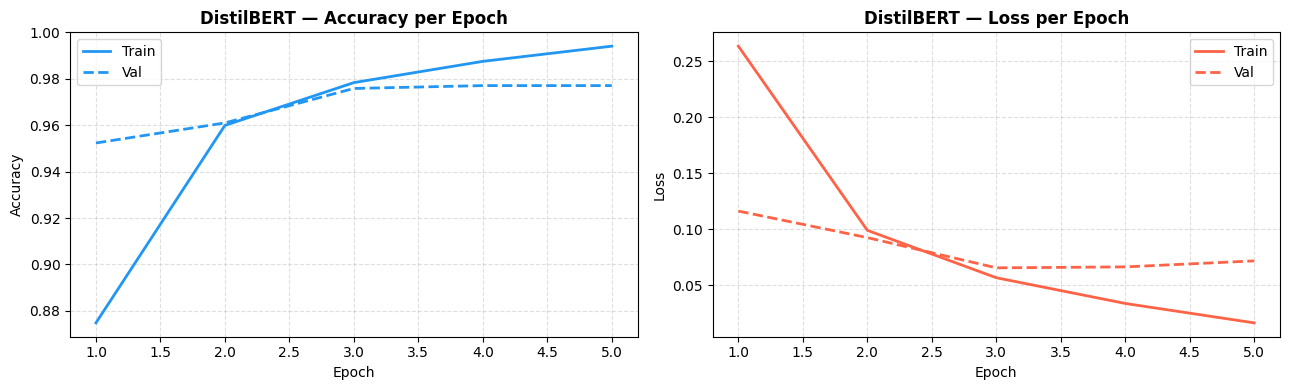

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, EPOCHS + 1)

axes[0].plot(epochs, train_acc_history, linewidth=2, color='#2196F3', label='Train')
axes[0].plot(epochs, val_acc_history,   linewidth=2, color='#2196F3', label='Val', linestyle='--')
axes[0].set_title('DistilBERT — Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(epochs, train_loss_history, linewidth=2, color='tomato', label='Train')
axes[1].plot(epochs, val_loss_history,   linewidth=2, color='tomato', label='Val', linestyle='--')
axes[1].set_title('DistilBERT — Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [40]:
# Evaluation function
def evaluate_distilbert(loader, label='clean'):
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits
            probs   = torch.softmax(logits, dim=1)[:, 1]
            preds   = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc     = auc(fpr, tpr)
    fnr         = 1 - tpr
    eer         = float(fpr[np.nanargmin(np.abs(fnr - fpr))])

    print(f'\n=== DistilBERT [{label.upper()}] ===')
    print(classification_report(all_labels, all_preds, target_names=['Legit', 'Phishing']))
    print(f'AUC: {roc_auc:.4f}')
    print(f'EER: {eer:.4f}')

    cm   = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Phishing'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=True)
    ax.set_title(f'DistilBERT — {label.title()} Emails', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds, all_probs, fpr, tpr, roc_auc, eer


=== DistilBERT [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99       735
    Phishing       1.00      0.99      0.99       613

    accuracy                           0.99      1348
   macro avg       0.99      0.99      0.99      1348
weighted avg       0.99      0.99      0.99      1348

AUC: 0.9998
EER: 0.0054


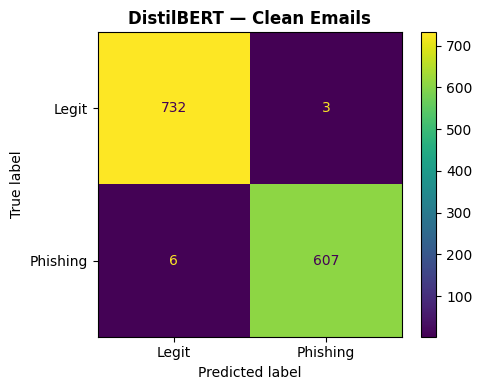

In [41]:
# Evaluate on clean
y_true_c, y_pred_c, y_prob_c, fpr_c, tpr_c, auc_c, eer_c = evaluate_distilbert(test_clean_loader, 'clean')


=== DistilBERT [MANIPULATED] ===
              precision    recall  f1-score   support

       Legit       0.97      0.97      0.97       735
    Phishing       0.97      0.96      0.96       613

    accuracy                           0.97      1348
   macro avg       0.97      0.97      0.97      1348
weighted avg       0.97      0.97      0.97      1348

AUC: 0.9947
EER: 0.0327


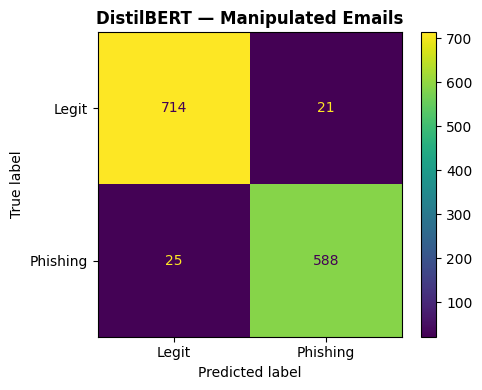

In [42]:
# Evaluate on manipulated
y_true_m, y_pred_m, y_prob_m, fpr_m, tpr_m, auc_m, eer_m = evaluate_distilbert(test_manip_loader, 'manipulated')

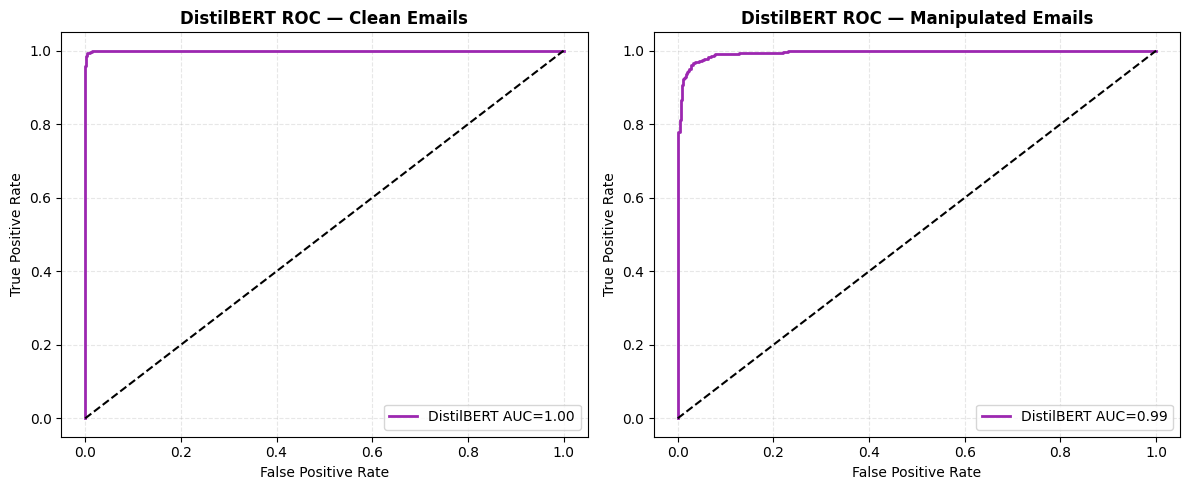

In [43]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_c, tpr_c, color='#9C27B0', linewidth=2, label=f'DistilBERT AUC={auc_c:.2f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('DistilBERT ROC — Clean Emails', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

axes[1].plot(fpr_m, tpr_m, color='#9C27B0', linewidth=2, label=f'DistilBERT AUC={auc_m:.2f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('DistilBERT ROC — Manipulated Emails', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

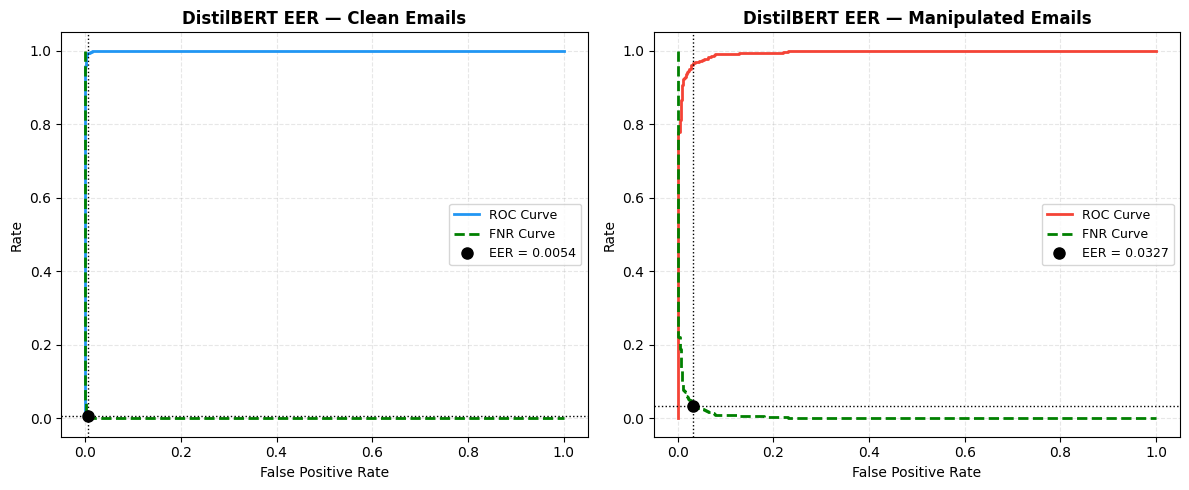

In [47]:
# EER Plot for DistilBERT
fpr_list  = [fpr_c, fpr_m]
tpr_list  = [tpr_c, tpr_m]
colors    = ['#2196F3', '#F44336']
labels    = ['Clean', 'Manipulated']
eers      = [eer_c, eer_m]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fpr, tpr, color, label, eer in zip(axes, fpr_list, tpr_list, colors, labels, eers):
    fnr = 1 - tpr
    ax.plot(fpr, tpr,  color=color,   linewidth=2, label='ROC Curve')
    ax.plot(fpr, fnr,  color='green', linewidth=2, label='FNR Curve', linestyle='--')
    ax.plot(eer, eer,  'ko', markersize=8, label=f'EER = {eer:.4f}')
    ax.axvline(x=eer,  color='black', linestyle=':', linewidth=1)
    ax.axhline(y=eer,  color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('Rate')
    ax.set_title(f'DistilBERT EER — {label} Emails', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('distilbert_eer_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Show examples of DistilBERT predictions
model.eval()

sample_indices = [0, 1, 2, 3, 4]  # first 5 emails from test set

print('='*70)
print('  DISTILBERT PREDICTION EXAMPLES')
print('='*70)

for idx in sample_indices:
    original_text  = X_test_text[idx]
    manip_text     = X_test_manip_text[idx]
    true_label     = y_test[idx]

    # Tokenize original
    inputs_orig = tokenizer(
        original_text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors='pt'
    ).to(device)

    # Tokenize manipulated
    inputs_manip = tokenizer(
        manip_text,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        out_orig  = model(**inputs_orig)
        out_manip = model(**inputs_manip)

    prob_orig  = torch.softmax(out_orig.logits,  dim=1)[0][1].item()
    prob_manip = torch.softmax(out_manip.logits, dim=1)[0][1].item()

    pred_orig  = 'PHISHING' if prob_orig  >= 0.5 else 'LEGIT'
    pred_manip = 'PHISHING' if prob_manip >= 0.5 else 'LEGIT'
    true_str   = 'PHISHING' if true_label == 1    else 'LEGIT'

    print(f'\nEmail #{idx+1}')
    print(f'True Label        : {true_str}')
    print(f'Original text     : {original_text[:120]}...')
    print(f'Manipulated text  : {manip_text[:120]}...')
    print(f'Prediction (orig) : {pred_orig}  (confidence: {prob_orig:.4f})')
    print(f'Prediction (manip): {pred_manip}  (confidence: {prob_manip:.4f})')
    print('-'*70)

  DISTILBERT PREDICTION EXAMPLES

Email #1
True Label        : LEGIT
Original text     : subject new turn ons tom production commenced to flow as stated below please create a base load ticket in sitara based u...
Manipulated text  : $ubj3c7 n3w 7urn 0n$ 70m pr0duc710n c0mm3nc3d 70 f10w @$ $7@73d b310w p13@$3 cr3@73 @ b@$3 10@d 71ck37 1n $17@r@ b@$3d u...
Prediction (orig) : LEGIT  (confidence: 0.0004)
Prediction (manip): LEGIT  (confidence: 0.0011)
----------------------------------------------------------------------

Email #2
True Label        : PHISHING
Original text     : subject oxyyyyconttin no script needeeed taaabbsittabbs cccheaapicheeep ssstttoooppp hhhhurting todayistop da pain now h...
Manipulated text  : $ubj3c7 0xyyyyc0n771n n0 $cr1p7 n33d333d 7@@@bb$177@bb$ ccch3@@p1ch333p $$$777000ppp hhhhur71n9 70d@y1$70p d@ p@1n n0w h...
Prediction (orig) : PHISHING  (confidence: 0.9997)
Prediction (manip): PHISHING  (confidence: 0.9994)
-----------------------------------------------